<a href="https://colab.research.google.com/github/SrishanthGorla/SERAI/blob/main/SERI1_1_Image_Classifier_Baseline_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
from tensorflow.keras.datasets import mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


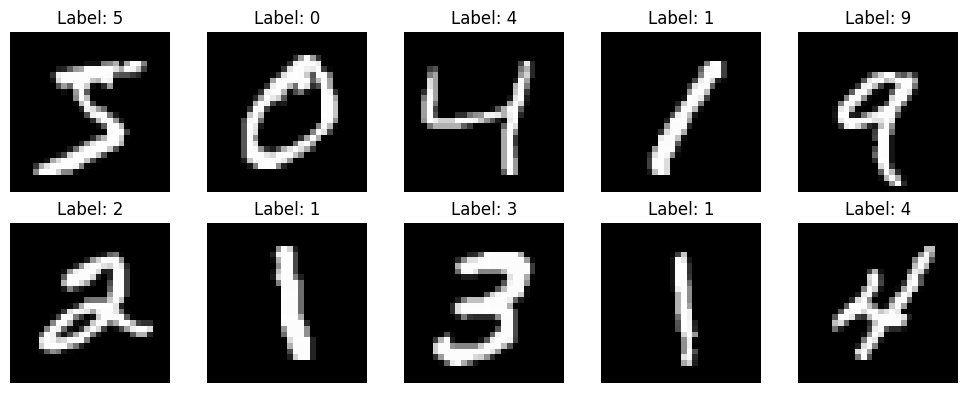

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 104ms/step - accuracy: 0.9342 - loss: 0.2210 - val_accuracy: 0.9765 - val_loss: 0.0744
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - accuracy: 0.9816 - loss: 0.0600 - val_accuracy: 0.9867 - val_loss: 0.0446
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9876 - loss: 0.0409 - val_accuracy: 0.9892 - val_loss: 0.0411
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9901 - loss: 0.0319 - val_accuracy: 0.9868 - val_loss: 0.0382
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9918 - loss: 0.0249 - val_accuracy: 0.9898 - val_loss: 0.0353


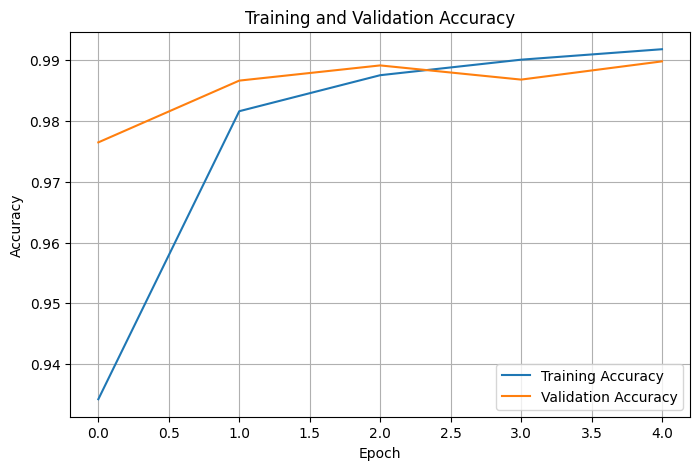

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.029193494468927383
Test Accuracy: 0.9901000261306763


In [ ]:
y_probability = model.predict(x_test)

y_pred = np.argmax(y_probability, axis=1)

print("Predictions generated successfully.")
print("First 20 predictions:")
print(y_pred[:20])

print("First 20 actual labels:")
print(y_test[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predictions generated successfully.
First 20 predictions:
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
First 20 actual labels:
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Baseline Performance")
print("--------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Baseline Performance
--------------------
Accuracy  : 0.9901
Precision : 0.9902
Recall    : 0.9901
F1-Score  : 0.9901


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.98      1.00      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



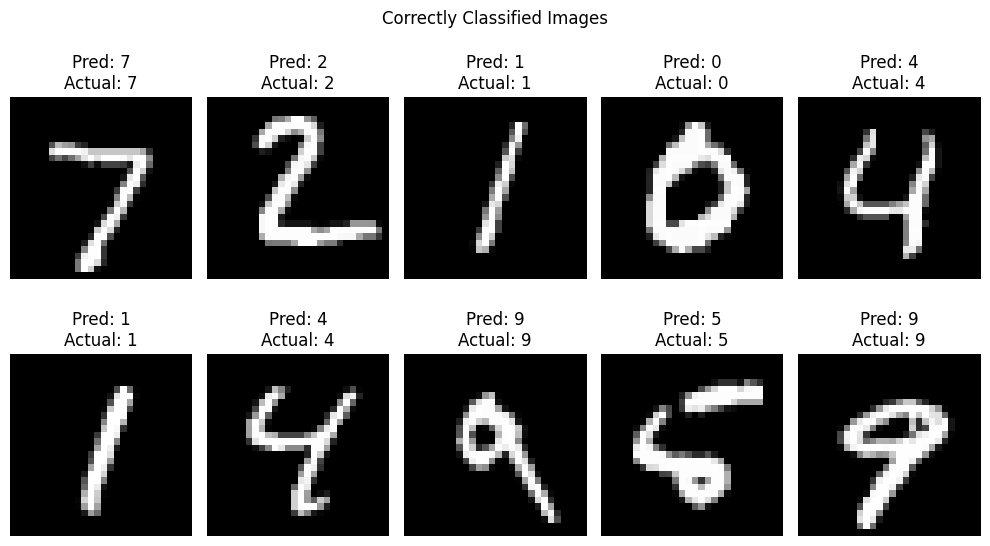

In [ ]:
correct_indices = np.where(y_pred == y_test)[0]

plt.figure(figsize=(10, 6))

for i, idx in enumerate(correct_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"Pred: {y_pred[idx]}\nActual: {y_test[idx]}")
    plt.axis('off')

plt.suptitle("Correctly Classified Images")
plt.tight_layout()
plt.show()

In [ ]:
incorrect_indices = np.where(y_pred != y_test)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 99


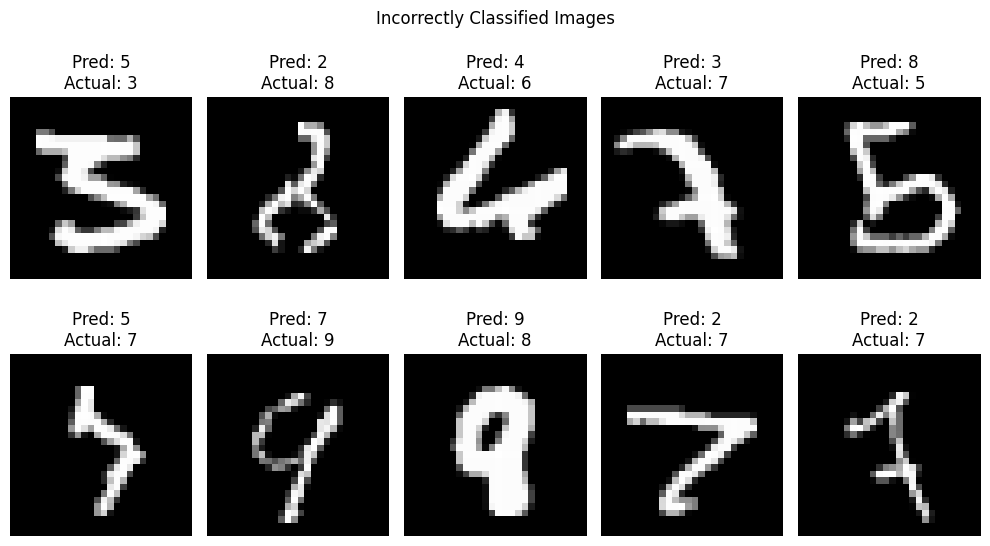

In [ ]:
plt.figure(figsize=(10, 6))

for i, idx in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"Pred: {y_pred[idx]}\nActual: {y_test[idx]}")
    plt.axis('off')

plt.suptitle("Incorrectly Classified Images")
plt.tight_layout()
plt.show()

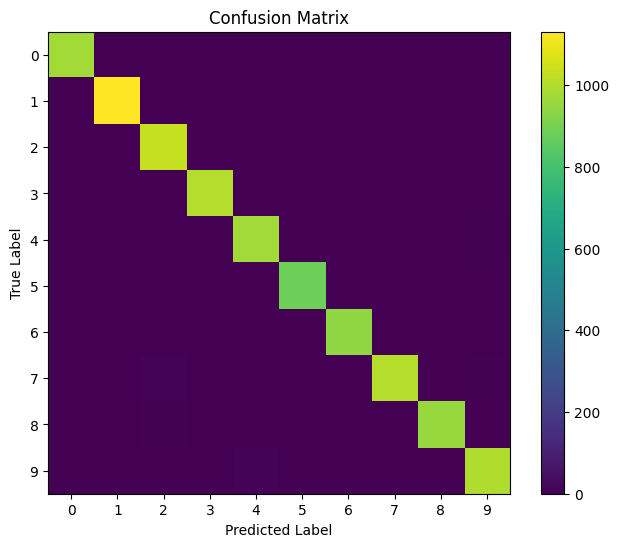

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()